# **CS 1810 Homework 3**
---

To account for potential version issues, try the following in your terminal:

1. Create a new environment with `python3 -m venv venv`
2. Activate that environment with `source venv/bin/activate`
3. Make sure the interpreter in the top right corner of your VSCode (or whatever you use to run your code is venv).
4. If you get a "install kernel" message, press it.
5. Run `pip install -r requirements.txt`
6. Run the remainder of this notebook.

Note that this is not necessary but can help prevent any issues due to package versions.

**The following notebook is meant to help you work through Problems 1 and 3 on Homework 3. You are by no means required to use it, nor are you required to fill out/use any of the boilerplate code/functions. You are welcome to implement the functions however you wish.**

# **Problem 1: Kernels and Feature Maps**
---

This section contains the coding portions of Problem 1.

- **Part 2a**: Plot the concentric circles dataset
- **Part 2b**: Implement the feature map and visualize in 3D
- **Part 2c**: Ridge regression in feature space
- **Part 3b**: Kernel ridge regression and alpha visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

## **Data Generation**

We generate a synthetic dataset of concentric circles. The inner ring (class 0) has radius $\approx 0.5$ and the outer ring (class 1) has radius $\approx 1.5$. We add a small amount of Gaussian noise to the radii.

In [2]:
rng = np.random.default_rng(181)

n = 400

# Inner ring (class 0)
theta_inner = rng.uniform(0, 2 * np.pi, n // 2)
r_inner = 0.5 + 0.1 * rng.standard_normal(n // 2)
X_inner = np.column_stack([r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)])

# Outer ring (class 1)
theta_outer = rng.uniform(0, 2 * np.pi, n // 2)
r_outer = 1.5 + 0.15 * rng.standard_normal(n // 2)
X_outer = np.column_stack([r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)])

X_all = np.vstack([X_inner, X_outer])
y_all = np.array([0] * (n // 2) + [1] * (n // 2))

# Train/test split (80/20)
perm = rng.permutation(n)
n_train = int(0.8 * n)
train_idx, test_idx = perm[:n_train], perm[n_train:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

print(f'Training set: {X_train.shape[0]} points')
print(f'Test set:     {X_test.shape[0]} points')

Training set: 320 points
Test set:     80 points


## **Part 2a: Plot the original data**

Plot the dataset in the original space $\mathbb{R}^2$. Are the data linearly separable? Explain briefly.

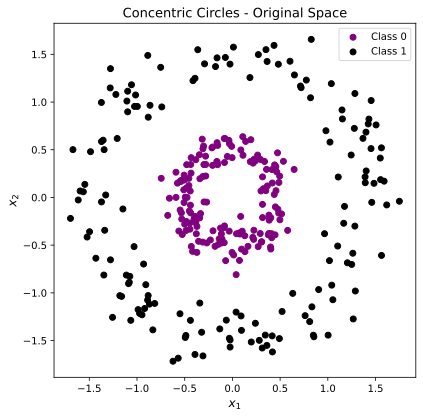

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
           label='Class 0', color='purple')
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
           label='Class 1', color='black')

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Concentric Circles - Original Space', fontsize=13)
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## **Part 2b: Feature map and 3D visualization**

Apply the feature map $\phi(\mathbf{x}) = (1,\; \sqrt{2}\,x_1,\; \sqrt{2}\,x_2,\; x_1^2,\; x_2^2,\; \sqrt{2}\,x_1 x_2)$ from Part 1 to the data. Produce a two-panel figure: the original 2D data on the left and a 3D scatter plot of $(x_1,\; x_2,\; x_1^2 + x_2^2)$ on the right, with points colored by class.

Are the data linearly separable in feature space? Why does this feature map help for concentric circles?

In [ ]:
def feature_map(X):
    """
    Apply the degree-2 polynomial feature map.

    :param X: data matrix of shape (N, 2)
    :return: feature matrix of shape (N, 6)
    """
    # TODO: Implement the feature map phi(x) = (1, sqrt(2)*x1, sqrt(2)*x2, x1^2, x2^2, sqrt(2)*x1*x2)

    # YOUR CODE HERE
    pass

In [ ]:
Phi_train = feature_map(X_train)

fig = plt.figure(figsize=(14, 6))

# --- Left panel: original 2D space ---
ax1 = fig.add_subplot(1, 2, 1)

# TODO: Plot the training data in (x1, x2) space, colored by class.

# YOUR CODE HERE
pass

ax1.set_xlabel('$x_1$', fontsize=12)
ax1.set_ylabel('$x_2$', fontsize=12)
ax1.set_title('Original space $(x_1, x_2)$', fontsize=13)
ax1.legend(fontsize=10)
ax1.set_aspect('equal')

# --- Right panel: 3D kernel lift ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# TODO: Plot (x1, x2, x1^2 + x2^2) from the training data, colored by class.

# YOUR CODE HERE
pass

ax2.set_xlabel('$x_1$', fontsize=11, labelpad=10)
ax2.set_ylabel('$x_2$', fontsize=11, labelpad=10)
ax2.set_zlabel('$x_1^2 + x_2^2$', fontsize=11, labelpad=10)
ax2.set_title('Feature space $(x_1, x_2, x_1^2 + x_2^2)$', fontsize=13)
ax2.legend(fontsize=9)
ax2.view_init(elev=15, azim=45)

fig.tight_layout(pad=3.0)
plt.show()

## **Part 2c: Ridge regression in feature space**

Fit a ridge regression model in the feature space:
$$\mathbf{w} = (\Phi^\top \Phi + \lambda I)^{-1} \Phi^\top \mathbf{y}$$

where $\Phi \in \mathbb{R}^{N \times 6}$ is the feature matrix with $\phi(\mathbf{x}_n)^\top$ as its $n$th row and $\mathbf{y} \in \{0, 1\}^N$ are the labels. Use $\lambda = 0.01$. Use pure `numpy` (no `sklearn`). Plot the decision boundary over the training data.

In [ ]:
# TODO: Implement ridge regression in the feature space.
# 1. Compute Phi_train using the feature_map function.
# 2. Solve for w using the normal equations with regularization lambda = 0.01.

# YOUR CODE HERE
pass

# Visualize the decision boundary in the original (x1, x2) space
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 300), np.linspace(-2.2, 2.2, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
Phi_grid = feature_map(grid)
zz = (Phi_grid @ w).reshape(xx.shape)

ax.contourf(xx, yy, zz, levels=[zz.min(), 0.5, zz.max()], colors=['#d4e6f1', '#fadbd8'], alpha=0.6)
ax.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=1.5)

ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='tab:blue', s=20, alpha=0.7, label='Class 0')
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='tab:red', s=20, alpha=0.7, label='Class 1')

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Ridge Regression Decision Boundary', fontsize=13)
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## **Part 3b: Kernel ridge regression and alpha visualization**

Implement kernel ridge regression using the polynomial kernel $K(\mathbf{x}, \mathbf{x}') = (1 + \mathbf{x}^\top \mathbf{x}')^2$. Compute the weight vector $\boldsymbol{\alpha} = (\mathbf{K} + \lambda I)^{-1} \mathbf{y}$ and make a scatter plot of the training data where each point is sized proportionally to $|\alpha_n|$.

In [ ]:
def polynomial_kernel(X1, X2):
    """
    Compute the degree-2 polynomial kernel matrix between X1 and X2.
    K(x, x') = (1 + x^T x')^2

    :param X1: data matrix of shape (N1, 2)
    :param X2: data matrix of shape (N2, 2)
    :return: kernel matrix of shape (N1, N2)
    """
    # TODO: Implement the polynomial kernel.

    # YOUR CODE HERE
    pass


def kernel_ridge_regression(K, y, lam):
    """
    Solve for alpha in kernel ridge regression: alpha = (K + lambda * I)^{-1} y.

    :param K: kernel matrix of shape (N, N)
    :param y: label vector of shape (N,)
    :param lam: regularization parameter
    :return: alpha vector of shape (N,)
    """
    # TODO: Solve for alpha.

    # YOUR CODE HERE
    pass


def predict(K_star, alpha):
    """
    Make predictions using kernel ridge regression: f(x*) = sum_n alpha_n K(x_n, x*).

    :param K_star: kernel matrix between test and training points, shape (N_test, N_train)
    :param alpha: alpha vector of shape (N_train,)
    :return: predictions of shape (N_test,)
    """
    # TODO: Compute predictions.

    # YOUR CODE HERE
    pass

In [ ]:
# TODO: Compute the kernel matrices, solve for alpha and predict on the test set.

# YOUR CODE HERE
pass

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

# Scale point sizes by |alpha_n|
alpha_abs = np.abs(alpha)
sizes = 300 * alpha_abs / alpha_abs.max()

# TODO: Plot the training data with sizes proportional to |alpha_n|.
# Use the `sizes` array above for the `s` parameter of ax.scatter. Color by class.

# YOUR CODE HERE
pass

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Training data sized by $|\\alpha_n|$', fontsize=13)
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# **Problem 3: Neural Scaling Laws**
---

This section contains the coding portions of Problem 3.

- **Part (a)(i)**: Define the ResNet architecture and train across model sizes
- **Part (a)(ii)**: Data-size sweep at fixed model depth
- **Part (a)(iii)**: Log-log fits and scaling exponents
- **Part (c)(i)**: Predict and verify at K=24
- **Part (c)(ii)**: Estimate blocks needed to close half the remaining gap

## **Imports and Setup**

We use PyTorch for model training, torchvision for the Fashion-MNIST dataset, and standard scientific Python libraries for analysis and plotting.

In [ ]:
import json
import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Fix all random seeds for reproducibility
seed = 181
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

## **Architecture: Depth-Scaled ResNet**

Before writing any code, let's understand what we're building. The architecture is a **ResNet** (Residual Network) — a CNN where each block has a "skip connection" that adds the block's input directly to its output. This helps gradients flow during backprop.

We scale model size by varying only the **depth** (number of residual blocks K) while keeping the channel width C=64 fixed. This gives us a clean, single-variable knob for model size.

The three parts of the network are:

1. **Stem:** Converts the raw 28×28 input image into a feature map. The MaxPool halves spatial size to 14×14.
2. **K × ResBlock:** Each residual block applies two convolutions and adds the original input back (the "skip"). The spatial size stays 14×14 throughout.
3. **Head:** Collapses the 14×14 feature map into a single vector, then classifies it into 10 classes.

### Your task: implement `ResBlock` and `ScaledResNet`

Each `ResBlock` should follow: `Conv → BN → ReLU → Conv → BN → (+skip) → ReLU`

`ScaledResNet` should assemble the stem, K blocks, and head as described above.

Also implement your parameter count formula in the param_count_formula function.

In [ ]:
import torch.nn.functional as F

BASE_CHANNELS = 64  # fixed width; we scale depth

class ResBlock(nn.Module):
    """Basic residual block: two 3x3 convs with BN and a skip connection."""

    def __init__(self, channels):
        super().__init__()
        #TODO: Define self.conv1, self.bn1, self.conv2, self.bn2
        # YOUR CODE HERE
        pass

    def forward(self, x):
        #TODO: perform the forward pass on x and return the output.
        # YOUR CODE HERE
        pass

class ScaledResNet(nn.Module):
    """ResNet with K residual blocks at a fixed channel width."""

    def __init__(self, num_blocks: int, base_channels: int = BASE_CHANNELS, num_classes: int = 10):
        super().__init__()
        # TODO: Define the three parts of the network as instance variables:
        # self.stem: the initial convolutional layer that processes the raw input image
        # self.blocks: a sequence of num_blocks residual blocks
        # self.pool: a pooling layer that collapses the spatial dimensions to 1x1
        # self.fc: a fully connected layer that maps to num_classes outputs
        # YOUR CODE HERE
        pass

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def param_count_formula(K: int, C: int = BASE_CHANNELS) -> int:
    #TODO: Count parameters for ScaledResNet with K blocks and base channels C.
    # YOUR CODE HERE
    pass
    return closed_form

print(f"Fixed base channels C = {BASE_CHANNELS}")
print(f"Per-block params: {18 * BASE_CHANNELS**2 + 4 * BASE_CHANNELS}")
print(f"Base params (stem+head): {21 * BASE_CHANNELS + 10}")
print()
for K in [1, 2, 3, 5, 8, 12, 18, 24]:
    print(f"K={K:>2} blocks -> N={param_count_formula(K):>10,}")

## **Experiment Configuration**

We set all hyperparameters here so they're easy to change. A few notes:

- **`MAX_EPOCHS = 40`**: We don't always train for 40 epochs — early stopping will halt training once the test loss stops improving.
- **`PATIENCE = 5`**: Stop training if the test loss hasn't improved by at least `MIN_DELTA` for 5 consecutive epochs.
- **`RUN_MODEL_SWEEP / RUN_DATA_SWEEP`**: Set these to `True` to run the training sweeps.

In [ ]:
# Core settings: depth scaling
K_VALUES = [1, 2, 3, 5, 8, 12, 18]   # number of residual blocks
D_VALUES = [1000, 2000, 5000, 10000, 20000, 30000, 50000]
FIXED_K_FOR_DATA_SWEEP = 12           # large model for data sweep

# Training settings
BATCH_SIZE = 256
MAX_EPOCHS = 40
PATIENCE = 10 # for early stopping
MIN_DELTA = 1e-4
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Run controls
RUN_DATA_SWEEP = True

RESULTS_DIR = Path("results_fashion_scaling")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_SWEEP_PATH = RESULTS_DIR / "depth_data_sweep.json"

print(f"Results directory: {RESULTS_DIR}")
print(f"Depth values (K): {K_VALUES}")
print(f"Fixed K for data sweep: {FIXED_K_FOR_DATA_SWEEP}")

## **Data Loading and Training Utilities**

Fashion-MNIST has 60,000 training and 10,000 test images of size 28×28 that show clothing items (t-shirts, trousers, sneakers, etc.).

### Your tasks:
1. **`make_test_loader`**: Return a `DataLoader` for the test set. Unlike training, we don't shuffle the test set.
2. **`evaluate_ce_loss`**: Run the model over a dataloader and return the average cross-entropy loss.
3. **`train_until_converged`** inner loop: Fill in the standard training step (move data to device → zero grad → forward → loss → backward → optimizer step).

In [ ]:
transform = transforms.ToTensor()

train_ds = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)
test_ds = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print(f"Train size: {len(train_ds)}")
print(f"Test size:  {len(test_ds)}")


def make_train_loader(dataset, subset_size=None, batch_size=256, seed=0):
    # returns the train DataLoader - use a random seed to ensure the dataloader shuffles the training set in a reproducible way
    g = torch.Generator() # Initialize g here
    g.manual_seed(seed)
    if subset_size is None or subset_size >= len(dataset):
        subset = dataset
    else:
        idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
        subset = Subset(dataset, idx)
    return DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, generator=g)


def make_test_loader(dataset, batch_size=512):
    g = torch.Generator()
    g.manual_seed(0)
    # TODO: returns the test DataLoader.
    # YOUR CODE HERE
    pass
    pass


def evaluate_ce_loss(model, loader, criterion, device):
    # TODO: Set the model to eval mode, then loop over the loader and accumulate
    # the total cross-entropy loss weighted by batch size. Return the average loss
    # across all examples.
    # YOUR CODE HERE
    pass
    pass


def train_until_converged(
    model,
    train_loader,
    test_loader,
    device,
    lr=1e-3,
    weight_decay=0.0,
    max_epochs=40,
    patience=5,
    min_delta=1e-4,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    hist = {"train_loss": [], "test_loss": []}
    best_test_loss = float("inf")
    best_state = None
    stale_epochs = 0

    for epoch in range(max_epochs):
        # TODO: set to train mode
        # YOUR CODE HERE
        pass
        total_train_loss = 0.0
        total_count = 0

        for x, y in train_loader:
            # TODO: Classic training loop!
            # Move x and y to device, run the forward pass to get logits,
            # compute the loss, backpropagate, and update the weights.
            # Zero the gradients before each step to avoid accumulation.
            # YOUR CODE HERE
            pass

            bs = x.size(0)
            total_train_loss += loss.item() * bs
            total_count += bs


        avg_train_loss = total_train_loss / max(total_count, 1)
        avg_test_loss = evaluate_ce_loss(model, test_loader, criterion, device)
        hist["train_loss"].append(avg_train_loss)
        hist["test_loss"].append(avg_test_loss)

        improved = best_test_loss - avg_test_loss > min_delta
        if improved:
            best_test_loss = avg_test_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        print(
            f"epoch={epoch+1:02d} train_ce={avg_train_loss:.4f} "
            f"test_ce={avg_test_loss:.4f} best={best_test_loss:.4f}"
        )

        if stale_epochs >= patience:
            print(f"Early stop at epoch {epoch+1} (patience={patience}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_test_loss, hist

## **Part (a)(i): Model-Size Sweep**

We provide pre-computed results from training 7 ResNets of increasing depth on the **full** Fashion-MNIST training set. Each model was trained to convergence (early stopping) and we record the best test cross-entropy loss. You will use these results to fit the model-size scaling law. The values here are provided for you to cut down on the time required for the question.

In [ ]:
test_loader = make_test_loader(test_ds, batch_size=512)

# Pre-computed model sweep results from training ResNets on the full Fashion-MNIST
# training set. These are provided so you can focus on the fitting and analysis.
MODEL_SWEEP = {
    1:  {"K":  1, "N":    75338, "test_loss": 0.33922, "epochs_ran": 20},
    2:  {"K":  2, "N":   149322, "test_loss": 0.26205, "epochs_ran": 15},
    3:  {"K":  3, "N":   223306, "test_loss": 0.24479, "epochs_ran": 16},
    5:  {"K":  5, "N":   371274, "test_loss": 0.24046, "epochs_ran": 15},
    8:  {"K":  8, "N":   593226, "test_loss": 0.23228, "epochs_ran": 20},
    12: {"K": 12, "N":   889162, "test_loss": 0.22527, "epochs_ran": 17},
    18: {"K": 18, "N":  1333066, "test_loss": 0.21952, "epochs_ran": 14},
}

print("Model sweep summary (pre-computed):")
for K in sorted(MODEL_SWEEP.keys()):
    row = MODEL_SWEEP[K]
    print(f"K={K:>2} blocks  N={row['N']:>10,}  test_ce={row['test_loss']:.5f}  epochs={row['epochs_ran']}")

## **Part (a)(ii): Data-Size Sweep**

Now we fix the model at K=12 (889,162 parameters) and vary the training set size from 500 to 40,000 examples. This lets us measure the **data scaling exponent** β. We hold out the full dataset (D=60,000) for extrapolation in Part (c).

**Why fix K=12?** We want a model large enough to overfit on small datasets (so we can see the data-size effect) and learn the true trends with enough data, but not so large that training becomes prohibitively slow.

In [ ]:
DATA_SWEEP = {}
if RUN_DATA_SWEEP:
    for D in D_VALUES:
        key = str(D)
        if key in DATA_SWEEP:
            print(f"[skip] D={D} already in cache")
            continue

        subset_size = int(D)
        train_loader = make_train_loader(
            train_ds,
            subset_size=subset_size,
            batch_size=BATCH_SIZE,
            seed=seed + int(D),
        )

        print(f"\n{'='*50}")
        print(f"Training K={FIXED_K_FOR_DATA_SWEEP}, D={D}")
        print(f"{'='*50}")

        torch.manual_seed(seed + int(D))
        model = ScaledResNet(FIXED_K_FOR_DATA_SWEEP).to(device)

        best_test_ce, hist = train_until_converged(
            model,
            train_loader,
            test_loader,
            device,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            min_delta=MIN_DELTA,
        )

        DATA_SWEEP[key] = {
            "D": int(D),
            "K": FIXED_K_FOR_DATA_SWEEP,
            "N": int(param_count_formula(FIXED_K_FOR_DATA_SWEEP)),
            "test_loss": float(best_test_ce),
            "epochs_ran": int(len(hist["test_loss"])),
            "history": hist,
        }

        with open(DATA_SWEEP_PATH, "w") as f:
            json.dump(DATA_SWEEP, f, indent=2)
        print(f"Saved data sweep progress to {DATA_SWEEP_PATH}")

print("\nData sweep summary:")
for D in D_VALUES:
    row = DATA_SWEEP.get(str(D))
    if row is None:
        continue
    print(f"D={str(D):>5} (used={row['D']:>5})  test_ce={row['test_loss']:.5f}  epochs={row['epochs_ran']}")

## **Part (a)(iii): Log-Log Fits and Scaling Exponents**

Now we fit power laws to the results above.

### How we estimate $L_\infty$

We can't know the true irreducible error $L_\infty$, so we approximate it with the best result we've observed:
- **Model-size plot:** $\hat{L}_\infty^{(N)}$ = test loss of the K=18 model (deepest in the sweep)
- **Data-size plot:** $\hat{L}_\infty^{(D)}$ = test loss with D=40,000 (largest subset in the sweep)

We then **exclude these anchor points from the fit** — they define $\hat{L}_\infty$, so including them in the regression would make the gap identically zero for those points (undefined in log space).

Run the following cell to fit a line in log-log space using `np.polyfit`, and return the slope and intercept.

In [ ]:
def fit_loglog_power(x, losses, L_inf_hat, fit_mask=None):
    x = np.asarray(x, dtype=float)
    losses = np.asarray(losses, dtype=float)
    gaps = losses - L_inf_hat

    valid = gaps > 0
    if fit_mask is not None:
        valid = valid & np.asarray(fit_mask, dtype=bool)

    x_fit = x[valid]
    y_fit = gaps[valid]

    coeff = np.polyfit(np.log(x_fit), np.log(y_fit), deg=1)
    slope, intercept = float(coeff[0]), float(coeff[1])
    return slope, intercept, valid, gaps


K_sorted = sorted(MODEL_SWEEP.keys())
N_vals = np.array([MODEL_SWEEP[K]["N"] for K in K_sorted], dtype=float)
L_model = np.array([MODEL_SWEEP[K]["test_loss"] for K in K_sorted], dtype=float)

D_vals = np.array([DATA_SWEEP[str(d)]["D"] for d in D_VALUES], dtype=float)
L_data = np.array([DATA_SWEEP[str(d)]["test_loss"] for d in D_VALUES], dtype=float)

# Use the largest/most-data config as L_inf_hat_N and L_inf_hat_D
L_inf_hat_N = float(MODEL_SWEEP[max(K_sorted)]["test_loss"])
L_inf_hat_D = float(DATA_SWEEP["50000"]["test_loss"])

# Fit masks: exclude anchor point that defines L_inf_hat
fit_mask_N = np.ones_like(N_vals, dtype=bool)
fit_mask_N[-1] = False  # exclude K=18 (largest model)

fit_mask_D = np.ones_like(D_vals, dtype=bool)
fit_mask_D[-1] = False  # exclude D=50,000 (largest subset, anchor)

slope_N, intercept_N, valid_N, gap_N = fit_loglog_power(N_vals, L_model, L_inf_hat_N, fit_mask=fit_mask_N)
slope_D, intercept_D, valid_D, gap_D = fit_loglog_power(D_vals, L_data, L_inf_hat_D, fit_mask=fit_mask_D)

alpha_hat = -slope_N
beta_hat = -slope_D
A_hat = math.exp(intercept_N)
B_hat = math.exp(intercept_D)

print(f"alpha_hat = {alpha_hat:.6f}  (exponent for model size)")
print(f"beta_hat  = {beta_hat:.6f}  (exponent for data size)")

# Plot 1: gap vs N
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.loglog(N_vals[gap_N > 0], gap_N[gap_N > 0], "o", markersize=8, label="measured")
N_line = np.geomspace(np.min(N_vals[valid_N]), np.max(N_vals[valid_N]), 200)
ax.loglog(N_line, np.exp(intercept_N) * (N_line ** slope_N), "--", label=f"fit: α̂={alpha_hat:.3f}")
ax.set_xlabel("N (parameter count)")
ax.set_ylabel("L − L̂∞")
ax.set_title("log(L − L̂∞) vs log(N)  [depth scaling]")
ax.grid(alpha=0.3)
ax.legend()

# Plot 2: gap vs D
ax = axes[1]
ax.loglog(D_vals[gap_D > 0], gap_D[gap_D > 0], "o", markersize=8, label="measured")
D_line = np.geomspace(np.min(D_vals[valid_D]), np.max(D_vals[valid_D]), 200)
ax.loglog(D_line, np.exp(intercept_D) * (D_line ** slope_D), "--", label=f"fit: β̂={beta_hat:.3f}")
ax.set_xlabel("D (dataset size)")
ax.set_ylabel("L − L̂∞")
ax.set_title("log(L − L̂∞) vs log(D)  [L̂∞ from D=40,000]")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## **Part (c)(i): Predict at D=60,000, then verify**

The real test of a scaling law: can you accurately predict performance at a scale you haven't trained at yet?

Using only the fitted data scaling law from Part (a)(iii), we predict the test loss when training on the **full** dataset (D=60,000). Then we actually train at D=60,000 and compare.

**Prediction formula** (from the data-size fit):

$$\hat{L}(D) = \hat{L}_\infty^{(D)} + \hat{B} \cdot D^{-\hat{\beta}}$$

where $\hat{B} = e^{\text{intercept}_D}$ and $-\hat{\beta} = \text{slope}_D$.

**Your task:** implement the prediction formula (L_pred) and compare to the true trained loss.

In [ ]:
D_PRED = 60000

#TODO: From log-log fit for D, predict the test loss at D=60,000.
# Call your variable L_pred.
# YOUR CODE HERE
pass

print(f"Predicted D={D_PRED:,}: test CE ≈ {L_pred:.6f}")

# Train at D=60,000 (full training set) to verify
print(f"\n{'='*50}")
print(f"Training K={FIXED_K_FOR_DATA_SWEEP} on full dataset (D={D_PRED:,})")
print(f"{'='*50}")

train_loader_full = make_train_loader(train_ds, subset_size=None, batch_size=BATCH_SIZE, seed=seed)
torch.manual_seed(seed)
model_extrap = ScaledResNet(FIXED_K_FOR_DATA_SWEEP).to(device)

best_test_ce_extrap, hist_extrap = train_until_converged(
    model_extrap,
    train_loader_full,
    test_loader,
    device,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
)

print(f"\nD={D_PRED:,} comparison:")
print(f"  predicted_test_loss = {L_pred:.6f}")
print(f"  true_test_loss      = {best_test_ce_extrap:.6f}")
print(f"  abs_error           = {abs(best_test_ce_extrap - L_pred):.6f}")

## **Part (c)(ii): How Much Data to Close Half the Gap?**

We've been getting diminishing returns as D grows — each doubling of data brings less improvement. This is exactly the power-law behavior at work.

**The question:** how many training examples would we need to reach a test loss **halfway between our best observed finite-data loss and $\hat{L}_\infty^{(D)}$**?

**Your task:** compute D_needed for the halfway target.

In [ ]:
# Best observed loss from the data sweep (excluding the anchor D=40,000)
anchor_D = max(D_VALUES)
non_anchor_losses = [DATA_SWEEP[str(D)]["test_loss"] for D in D_VALUES if D != anchor_D]
second_best = min(non_anchor_losses)

# TODO: Compute D_needed_halfway (call your variable this name) — the number of training examples needed
# to reach a test loss halfway between second_best and L_inf_hat_D.
# YOUR CODE HERE
pass

print(f"L_inf_hat_D               = {L_inf_hat_D:.6f}")
print(f"second_best (data sweep)  = {second_best:.6f}")
print(f"target_loss_halfway       = {target_loss_halfway:.6f}")
print(f"gap_target                = {gap_target:.6f}")
print(f"D_needed_halfway          = {D_needed_halfway:,.0f} training examples")